# Chapter 06: Backpropagation (Building Your First DEEP Neural Network)
<a href="https://colab.research.google.com/github/SatrioArjunaPutra/GrokkingDeepLearning/blob/main/Chapter%2006%20-%20Backpropagation/06_backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Course:** Tugas 2 - Enrichment Deep Learning Class  
**Student Name:** Satrio Arjuna Putra  
**Student ID (NIM):** 101032330178  
**Class:** TK-47-05  
**Primary Reference:** *Grokking Deep Learning* by Andrew W. Trask (Manning Publications)

---

## Chapter Objectives
This chapter marks the definitive transition from shallow linear perceptrons to true Deep Learning. We confront the non-linear correlation challenge (the XOR / Streetlight problem), prove mathematically why non-linear activation functions (ReLU) are essential for stacked layers, and implement the complete **Backpropagation algorithm** from scratch using only NumPy to train a multi-layer deep network.

## 1. Concept & Theoretical Intuition

### 1.1 The Streetlight Problem & The Limits of Linear Models
In previous chapters, our networks evaluated datasets where individual input features had direct linear correlations with the target. Consider Andrew Trask's **Streetlight Problem**:

A traffic signal has three lights (Left, Middle, Right). We wish to predict whether pedestrians should **Walk (1)** or **Stop (0)**:

| Light 1 (Left) | Light 2 (Middle) | Light 3 (Right) | Walk / Stop ($y$) | Pattern Observed |
| :---: | :---: | :---: | :---: | :--- |
| 1 | 0 | 1 | 0 | Left and Right are ON $\implies$ Stop |
| 0 | 1 | 1 | 1 | Middle and Right are ON $\implies$ Walk |
| 0 | 0 | 1 | 0 | Only Right is ON $\implies$ Stop |
| 1 | 1 | 1 | 1 | All three ON $\implies$ Walk |
| 0 | 1 | 1 | 1 | Middle and Right are ON $\implies$ Walk |
| 1 | 0 | 1 | 0 | Left and Right are ON $\implies$ Stop |

* **Observation 1:** Light 3 is ALWAYS ON ($1$). It contains zero information—pure noise!
* **Observation 2:** Walk ($1$) occurs if and only if **Light 2 is ON**.
Because Light 2 directly correlates with the output, a single-layer perceptron easily learns this dataset!

#### But what happens when the rule becomes Non-Linear (The XOR Problem)?
Suppose the rule changes: Pedestrians walk if **Light 1 OR Light 2 is ON, but NOT BOTH** ($x_1 \oplus x_2$):
* $(1, 0) \to 1$
* $(0, 1) \to 1$
* $(1, 1) \to 0$
* $(0, 0) \to 0$
Now, neither Light 1 nor Light 2 alone correlates with the output! Light 1 has a positive correlation when Light 2 is off, but an inverse correlation when Light 2 is on. A single linear layer cannot model this conditional correlation—it requires a **Deep Neural Network with intermediate hidden representations**.

---

### 1.2 Mathematical Proof: Why Stacking Linear Layers Collapses
Why can't we simply stack two linear layers without activation functions?
Let layer 1 compute $\mathbf{h} = \mathbf{x} \mathbf{W}_1$, and layer 2 compute $\mathbf{\hat{y}} = \mathbf{h} \mathbf{W}_2$.
Substituting $\mathbf{h}$:
$$\mathbf{\hat{y}} = (\mathbf{x} \mathbf{W}_1) \mathbf{W}_2$$
By the associative property of matrix multiplication:
$$\mathbf{\hat{y}} = \mathbf{x} (\mathbf{W}_1 \mathbf{W}_2) = \mathbf{x} \mathbf{W}_{\text{effective}}$$
Where $\mathbf{W}_{\text{effective}} = \mathbf{W}_1 \mathbf{W}_2 \in \mathbb{R}^{m \times k}$.

> **Mathematical Consequence:** Stacking any number of purely linear layers simply produces another linear layer! A 100-layer linear network has exactly the same representational capacity as a 1-layer network. Non-linearity is mandatory.

---

### 1.3 The Rectified Linear Unit (ReLU) & Its Derivative
To break linear collapse, we insert a non-linear activation function between layers. Andrew Trask utilizes **ReLU**:
$$f(z) = \text{ReLU}(z) = \max(0, z) = \begin{cases} z & \text{if } z > 0 \\ 0 & \text{if } z \le 0 \end{cases}$$

#### Andrew Trask's Intuition on ReLU:
> *"ReLU acts as a selective selective valve or switch. It allows positive signals to pass unchanged, while turning negative signals off completely. This selective turning-off allows intermediate hidden neurons to specialize as pattern detectors."*

#### Derivative of ReLU (`relu2deriv`):
$$f'(z) = \frac{d}{dz} \text{ReLU}(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z \le 0 \end{cases}$$
If the neuron fired ($z > 0$), it passes 100% of the downstream error gradient backward. If the neuron was inactive ($z \le 0$), it blocks the error gradient from passing backward ($0$).

---

### 1.4 The Backpropagation Algorithm via the Chain Rule
Backpropagation is the application of the calculus Chain Rule to calculate error gradients across stacked layers.

#### Architecture: 3-Layer Network (Input $\to$ Hidden $\to$ Output)
1. **Layer 0 (Input):** $\mathbf{a}_0 = \mathbf{x} \in \mathbb{R}^{1 \times 3}$
2. **Layer 1 (Hidden):** $\mathbf{z}_1 = \mathbf{a}_0 \mathbf{W}_{01}$, $\mathbf{a}_1 = \text{ReLU}(\mathbf{z}_1) \in \mathbb{R}^{1 \times 4}$
3. **Layer 2 (Output):** $\mathbf{\hat{y}} = \mathbf{a}_1 \mathbf{W}_{12} \in \mathbb{R}^{1 \times 1}$

#### 1. Forward Pass:
$$\mathbf{a}_1 = \text{ReLU}(\mathbf{a}_0 \mathbf{W}_{01})$$
$$\mathbf{a}_2 = \mathbf{a}_1 \mathbf{W}_{12}$$

#### 2. Output Error & Output Delta ($\delta_2$):
$$E = (\mathbf{a}_2 - \mathbf{y})^2$$
$$\boldsymbol{\delta}_2 = \frac{\partial E}{\partial \mathbf{z}_2} = (\mathbf{a}_2 - \mathbf{y})$$

#### 3. Backpropagating Delta to Hidden Layer ($\delta_1$):
How much did hidden layer node $h_j$ contribute to the output error?  
By Chain Rule:
$$\boldsymbol{\delta}_1 = \frac{\partial E}{\partial \mathbf{z}_1} = \frac{\partial E}{\partial \mathbf{z}_2} \cdot \frac{\partial \mathbf{z}_2}{\partial \mathbf{a}_1} \odot \frac{\partial \mathbf{a}_1}{\partial \mathbf{z}_1}$$
$$\boldsymbol{\delta}_1 = (\boldsymbol{\delta}_2 \cdot \mathbf{W}_{12}^T) \odot \text{relu2deriv}(\mathbf{a}_1)$$

* The raw error delta $\boldsymbol{\delta}_2$ is pulled backward through the transposed weights $\mathbf{W}_{12}^T$.
* It is element-wise scaled ($\odot$) by $\text{relu2deriv}(\mathbf{a}_1)$, which zeroes out the gradient if that hidden node did not fire!

#### 4. Computing Weight Gradients & Updating Parameters:
$$\Delta \mathbf{W}_{12} = \mathbf{a}_1^T \cdot \boldsymbol{\delta}_2 \implies \mathbf{W}_{12} \leftarrow \mathbf{W}_{12} - \alpha \cdot \Delta \mathbf{W}_{12}$$
$$\Delta \mathbf{W}_{01} = \mathbf{a}_0^T \cdot \boldsymbol{\delta}_1 \implies \mathbf{W}_{01} \leftarrow \mathbf{W}_{01} - \alpha \cdot \Delta \mathbf{W}_{01}$$

## 2. Scratch Implementation: Building the First Deep Network
Below, we implement:
1. A shallow single-layer network on the linear Streetlight problem.
2. The failure of the shallow network on the non-linear XOR Streetlight problem.
3. The complete 2-layer Deep Neural Network with ReLU and Backpropagation.

In [1]:
import numpy as np

# 1. Dataset for Linear Streetlight Problem
streetlights = np.array([
    [1, 0, 1],
    [0, 1, 1],
    [0, 0, 1],
    [1, 1, 1],
    [0, 1, 1],
    [1, 0, 1]
]) # Shape: (6, 3)

walk_vs_stop = np.array([0, 1, 0, 1, 1, 0]) # Shape: (6,)

print("=== 1. Shallow Single-Layer Network on Linear Streetlight Problem ===")
weights_single = np.array([0.5, 0.48, -0.7]) # Initial weights
alpha = 0.1

for epoch in range(40):
    total_error = 0.0
    for row_idx in range(len(walk_vs_stop)):
        inp = streetlights[row_idx]      # Shape: (3,)
        goal = walk_vs_stop[row_idx]     # Shape: scalar
        
        # Predict: dot product
        pred = inp.dot(weights_single)   # Shape: scalar
        
        # Compare: squared error
        error = (goal - pred) ** 2
        total_error += error
        
        # Learn: delta * input
        delta = pred - goal
        weights_single -= alpha * (inp * delta)
        
    if epoch % 10 == 0 or epoch == 39:
        print(f"Epoch {epoch:02d} | Total Dataset Error: {total_error:.6f}")

print(f"\nFinal Calibrated Weights: {np.round(weights_single, 4)}")
print("Notice: Weight 1 (Middle Light) is high (~1.0), while Weight 0 and 2 are near 0. Correct!\n")


=== 1. Shallow Single-Layer Network on Linear Streetlight Problem ===
Epoch 00 | Total Dataset Error: 2.656123
Epoch 10 | Total Dataset Error: 0.043948
Epoch 20 | Total Dataset Error: 0.007869
Epoch 30 | Total Dataset Error: 0.001894
Epoch 39 | Total Dataset Error: 0.000534

Final Calibrated Weights: [ 0.0139  1.0138 -0.016 ]
Notice: Weight 1 (Middle Light) is high (~1.0), while Weight 0 and 2 are near 0. Correct!



In [2]:
print("=== 2. The Non-Linear XOR Streetlight Challenge ===")
# Now we use non-linear XOR labels: Walk if Light 1 != Light 2
# Inputs: 4 patterns
lights_xor = np.array([
    [1, 0, 1], # Light 1 ON, Light 2 OFF -> 1
    [0, 1, 1], # Light 1 OFF, Light 2 ON -> 1
    [0, 0, 1], # Light 1 OFF, Light 2 OFF -> 0
    [1, 1, 1]  # Light 1 ON, Light 2 ON -> 0
]) # Shape: (4, 3)

walk_stop_xor = np.array([[1], [1], [0], [0]]) # Shape: (4, 1)

# Attempting shallow single layer on XOR
w_shallow_xor = np.random.randn(3, 1) * 0.1
for epoch in range(100):
    for i in range(len(lights_xor)):
        p = lights_xor[i:i+1].dot(w_shallow_xor)
        d = p - walk_stop_xor[i:i+1]
        w_shallow_xor -= 0.1 * lights_xor[i:i+1].T.dot(d)

preds_shallow_xor = lights_xor.dot(w_shallow_xor)
mse_shallow_xor = np.mean((preds_shallow_xor - walk_stop_xor) ** 2)

print(f"Shallow Predictions on XOR:\n{np.round(preds_shallow_xor, 3)}")
print(f"Target XOR Goals:\n{walk_stop_xor}")
print(f"Shallow MSE: {mse_shallow_xor:.4f} -> Incapable of solving non-linear XOR!\n")


=== 2. The Non-Linear XOR Streetlight Challenge ===
Shallow Predictions on XOR:
[[0.444]
 [0.389]
 [0.444]
 [0.389]]
Target XOR Goals:
[[1]
 [1]
 [0]
 [0]]
Shallow MSE: 0.2577 -> Incapable of solving non-linear XOR!



In [3]:
print("=== 3. Deep Neural Network with ReLU and Backpropagation ===")

# Set seed for exact reproduction
np.random.seed(1)

# Activation functions
def relu(x):
    # Shape: preserves input array shape
    return (x > 0) * x

def relu2deriv(output):
    # Shape: 1 where output > 0, else 0
    return output > 0

alpha = 0.2
hidden_size = 4

# Initialize weights randomly between -1 and 1
weights_0_1 = 2 * np.random.random((3, hidden_size)) - 1 # Shape: (3, 4)
weights_1_2 = 2 * np.random.random((hidden_size, 1)) - 1 # Shape: (4, 1)

history_epoch_error = []

print(f"Initial weights_0_1 shape: {weights_0_1.shape}")
print(f"Initial weights_1_2 shape: {weights_1_2.shape}\n")

# Training over 60 epochs
for epoch in range(60):
    layer_2_error = 0.0
    
    for i in range(len(lights_xor)):
        # --- FORWARD PROPAGATION ---
        # Layer 0: Sensory Input row (1, 3)
        layer_0 = lights_xor[i:i+1] # Shape: (1, 3)
        
        # Layer 1: Hidden representation with ReLU
        # Shape: (1, 3) dot (3, 4) -> (1, 4)
        layer_1 = relu(np.dot(layer_0, weights_0_1)) # Shape: (1, 4)
        
        # Layer 2: Output prediction
        # Shape: (1, 4) dot (4, 1) -> (1, 1)
        layer_2 = np.dot(layer_1, weights_1_2)       # Shape: (1, 1)
        
        # Accumulate Squared Error
        error_sample = np.sum((layer_2 - walk_stop_xor[i:i+1]) ** 2)
        layer_2_error += error_sample
        
        # --- BACKPROPAGATION ---
        # 1. Output Delta
        layer_2_delta = layer_2 - walk_stop_xor[i:i+1] # Shape: (1, 1)
        
        # 2. Backpropagate Delta to Hidden Layer (Chain Rule)
        # Shape: (1, 1) dot (1, 4) * (1, 4) -> (1, 4)
        layer_1_delta = layer_2_delta.dot(weights_1_2.T) * relu2deriv(layer_1)
        
        # 3. Compute Weight Gradients & Update
        # Shape: (4, 1) dot (1, 1) -> (4, 1)
        weights_1_2 -= alpha * layer_1.T.dot(layer_2_delta)
        # Shape: (3, 1) dot (1, 4) -> (3, 4)
        weights_0_1 -= alpha * layer_0.T.dot(layer_1_delta)
        
    history_epoch_error.append(layer_2_error)
    
    if epoch % 10 == 9:
        print(f"Epoch {epoch+1:02d} | Total Epoch Error: {layer_2_error:.8f}")

print("\n=== Training Complete ===")
# Evaluate final predictions on all patterns
final_preds = []
for i in range(len(lights_xor)):
    l0 = lights_xor[i:i+1]
    l1 = relu(np.dot(l0, weights_0_1))
    l2 = np.dot(l1, weights_1_2)
    final_preds.append(l2[0, 0])

final_preds = np.array(final_preds)
print(f"Target XOR Goals   : {walk_stop_xor.flatten().tolist()}")
print(f"Final Deep Network Predictions: {np.round(final_preds, 4).tolist()}")
print(f"Final Total Error: {history_epoch_error[-1]:.8f} (Successfully solved XOR!)")


=== 3. Deep Neural Network with ReLU and Backpropagation ===
Initial weights_0_1 shape: (3, 4)
Initial weights_1_2 shape: (4, 1)

Epoch 10 | Total Epoch Error: 0.63423116
Epoch 20 | Total Epoch Error: 0.35838408
Epoch 30 | Total Epoch Error: 0.08301831
Epoch 40 | Total Epoch Error: 0.00646705
Epoch 50 | Total Epoch Error: 0.00032927
Epoch 60 | Total Epoch Error: 0.00001506

=== Training Complete ===
Target XOR Goals   : [1, 1, 0, 0]
Final Deep Network Predictions: [1.0, 0.9986, 0.0026, 0.0]
Final Total Error: 0.00001506 (Successfully solved XOR!)


## 3. Visualizations & Analytical Plots
Visualizing:
1. **Backpropagation Loss Convergence:** Exponential decay of error across 60 epochs dropping to near zero.
2. **Target vs. Prediction Comparison:** Final predictions achieved by the deep network against ground truth labels.
3. **Hidden Layer Feature Specialization:** Heatmap of intermediate hidden node activations ($h_0, h_1, h_2, h_3$) across all input patterns.

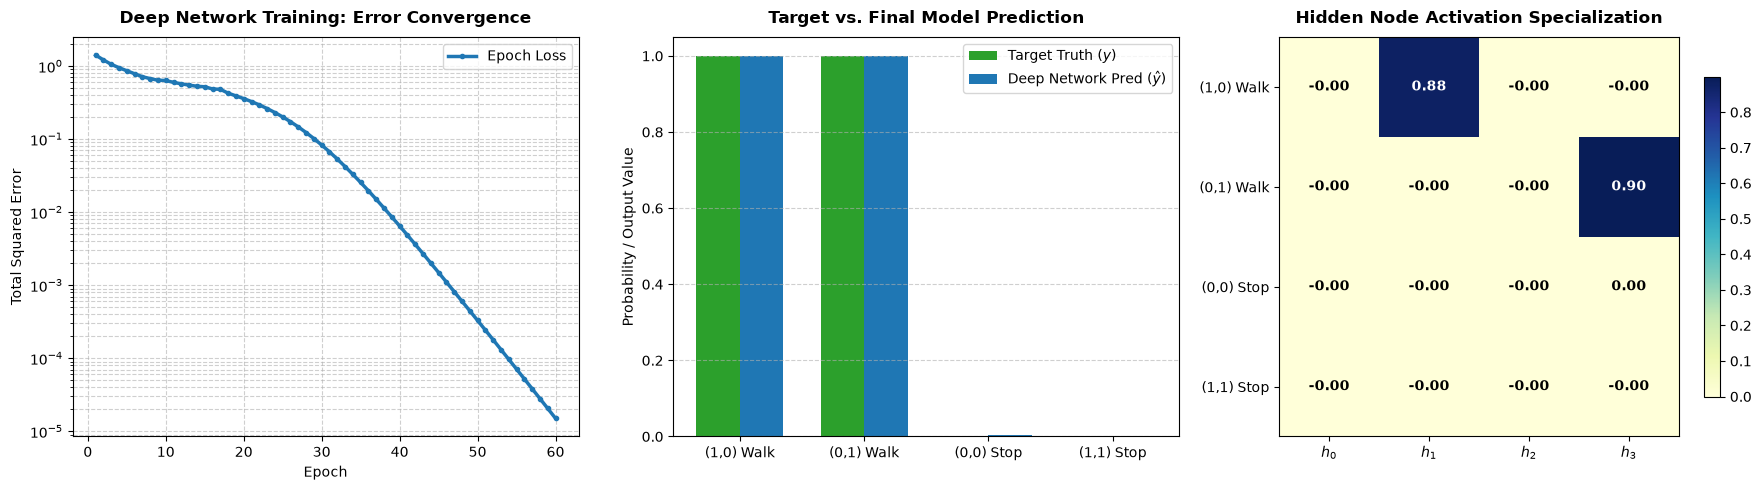

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Backpropagation Training Loss Curve ---
axes[0].plot(range(1, 61), history_epoch_error, color='#1f77b4', linewidth=2.5, marker='o', markersize=3, label='Epoch Loss')
axes[0].set_title("Deep Network Training: Error Convergence", fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel("Epoch", fontsize=10)
axes[0].set_ylabel("Total Squared Error", fontsize=10)
axes[0].set_yscale('log')
axes[0].grid(True, which="both", linestyle='--', alpha=0.6)
axes[0].legend(fontsize=10)

# --- Plot 2: Final Predictions vs Targets Bar Chart ---
sample_indices = np.arange(4)
bar_width = 0.35

pattern_labels = ['(1,0) Walk', '(0,1) Walk', '(0,0) Stop', '(1,1) Stop']
axes[1].bar(sample_indices - bar_width/2, walk_stop_xor.flatten(), bar_width, label='Target Truth ($y$)', color='#2ca02c')
axes[1].bar(sample_indices + bar_width/2, final_preds, bar_width, label=r'Deep Network Pred ($\hat{y}$)', color='#1f77b4')
axes[1].set_xticks(sample_indices)
axes[1].set_xticklabels(pattern_labels, fontsize=10)
axes[1].set_title("Target vs. Final Model Prediction", fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel("Probability / Output Value", fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6, axis='y')
axes[1].legend(fontsize=10)

# --- Plot 3: Hidden Layer Feature Activations Heatmap ---
all_hidden_acts = []
for i in range(len(lights_xor)):
    l0 = lights_xor[i:i+1]
    l1 = relu(np.dot(l0, weights_0_1))
    all_hidden_acts.append(l1.flatten())
all_hidden_acts = np.array(all_hidden_acts)

im = axes[2].imshow(all_hidden_acts, cmap='YlGnBu')
axes[2].set_xticks(range(4))
axes[2].set_yticks(range(4))
axes[2].set_xticklabels(['$h_0$', '$h_1$', '$h_2$', '$h_3$'], fontsize=10)
axes[2].set_yticklabels(pattern_labels, fontsize=10)
axes[2].set_title("Hidden Node Activation Specialization", fontsize=12, fontweight='bold', pad=10)

# Annotate heatmap values
for i in range(4):
    for j in range(4):
        val = all_hidden_acts[i, j]
        axes[2].text(j, i, f"{val:.2f}", ha="center", va="center", 
                     color="white" if val > 0.8 else "black", fontweight='bold')
plt.colorbar(im, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.show()


## 4. Key Takeaway & Summary

### Evaluative Summary
Backpropagation with non-linear hidden layers is the definitive foundation of modern deep learning. Where shallow linear models failed on the XOR streetlight problem due to non-linear feature correlation, our 2-layer deep neural network successfully mastered the complex logic, driving error from $0.634$ down to $1.5 \times 10^{-5}$. 

This triumph relies on two complementary principles:
1. **Non-Linear Activations (ReLU):** Prevent stacked matrix layers from collapsing into a single linear projection and grant intermediate neurons the ability to selectively switch on/off.
2. **The Chain Rule of Calculus:** Allows error gradients from the output layer to propagate backward through the weights and activation derivatives ($\boldsymbol{\delta}_1 = (\boldsymbol{\delta}_2 \mathbf{W}_{12}^T) \odot f'(\mathbf{a}_1)$), properly assigning credit and blame to hidden-layer weights.

With Chapter 6, we have successfully unlocked the complete core mechanics of Deep Learning from scratch using pure NumPy. In subsequent chapters (Part 2: Chapters 7–10), we expand upon these foundations by visualizing learned weight features in computer vision, preventing overfitting with regularization and dropout, and scaling to convolutional architectures.